## Logistic regression
Logistic regression is a simple and commonly used machine learning algorithm for two-class classification. It is used to describe data and to explain the relationship between one dependent binary variable and one or more nominal, ordinal, interval or ratio-level independent variables. Logistic regression can be used to answer questions such as:
* How does the probability of getting lung cancer (yes vs. no) change for every additional pound a person is overweight and for every pack of cigarettes smoked per day?
* Do body weight, calorie intake, fat intake, and age have an influence on the probability of having a heart attack (yes vs. no)?

Logistic regression can also be used for multi-class predictions, but we not cover that.

In general, logistic regression uses a linear combination of more than one feature value or explanatory variable as argument of the sigmoid function. The corresponding output of the sigmoid function is a number between 0 and 1. 

<img width="400px" src="images/sigmoid_figure.png" />

The middle value is considered as threshold to establish what belong to the class 1 and to the class 0. In particular, an input producing an outcome greater than 0.5 is considered belong to the class 1. Conversely, if the output is less than 0.5, then the corresponding input is classified as belonging to 0 class

## Logistic regression
For our implementation of logistic regression, we will use skikit-learn's LogisticRegression model:
* https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Let's load the libraries we will be using.

In [1]:
import pandas as pds
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

For our data, we will use the **Pima Indians Diabetes** dataset we used in the tree classifier tutorial.

The dataset includes data from 768 women. The columns are defined as follows:

* `Pregnancies`: Number of times pregnant
* `Glucose`: Plasma glucose concentration a 2 hours in an oral glucose tolerance test
* `BloodPressure`: Diastolic blood pressure (mm Hg)
* `SkinThickness`: Triceps skin fold thickness (mm)
* `Insulin`: 2-Hour serum insulin (mu U/ml)
* `BMI`: Body mass index (weight in kg/(height in m)^2)
* `DiabetesPedigreeFunction`: The output of the pedigree function that provides measure of genetic influence and gives us an idea of the hereditary risk one might have with the onset of diabetes mellitus
* `Age`: Age (years)
* `Outcome`: Class variable (0 or 1) 268 of 768 are 1 (positive), the others are 0 (negative)

In [2]:
## load Pima Indians Diabetes dataset (downloaded May 14, 2019; N=768)
df = pds.read_csv("diabetes.csv")

In the tree classifer tutorial, we already inspected the data. So, we are going to skip that step. But, we still need to drop the invalid rows.

In [3]:
## funciton to determine of a row has an invalid value
def valid_value(row):
    if 0 == row['Glucose'] or \
       0 == row['BloodPressure'] or \
       0 == row['SkinThickness'] or \
       0 == row['Insulin'] or \
       0 == row['BMI'] or \
       0 == row['Age']:
        return False
    else:
        return True

## create dataframe with only valid rows
df_pima = df[df.apply(lambda row: valid_value(row), axis=1)]
df_pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1


In [4]:
print(f"length of original dataframe:{len(df)}")
print(f"length of filtered dataframe:{len(df_pima)}")

length of original dataframe:768
length of filtered dataframe:392


Now we split the data into our training and test sets.

Recall that by convention, scikit-learn often refers to the feature dataset as `X` and the target dataset as `y`.


In [5]:
## split dataset in features and target variable
feature_cols = \
    ['Pregnancies', 'Insulin', 'BMI', 'Age','Glucose',
     'BloodPressure','DiabetesPedigreeFunction', 'SkinThickness']

X = df_pima[feature_cols]
y = df_pima['Outcome']

In [6]:
## split dataset into training set and test set
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test


Finally, the test and training data is fit to our model and we predict outcomes.

In [7]:
## create a logistic regression classifier and predict
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


## Evaluating logistic regression
To evaluate our logistic regression model, we will exame the confusion matrix, accuracy score, recall score, precision score, f1 score, and classifion report. 

**Accuracy:**
* (TP + TN) / (TP + TN + FP + FN)
* Accuracy is the ratio of correct predictions to total predictions made. However, there are problems with accuracy. It assumes equal costs for both kinds of errors. A 99% accuracy can be excellent, good, mediocre, poor or terrible depending upon the problem.


**Recall:**
* TP / (TP + FN)
* Recall is the ability of a classifier to find all positive instances. High recall indicates a small number of false negatives.


**Precision:**
* TP / (TP + FP)
* Precision is the ability of a classifier not to label an instance positive that is actually negative. High precision indicates a small number of false positives.

**F1 score (F measure):**
* (2 * Recall * Precision) / (Recall + Precision)
* Since we have two measures (Precision and Recall) it helps to have a measurement that represents both of them. We calculate an F1 score that uses Harmonic Mean in place of Arithmetic Mean as it punishes the extreme values more. 

In [8]:
def show_confusion_matrix(y_test, y_pred, palette="Set3"):
    ## see: https://www.geeksforgeeks.org/confusion-matrix-machine-learning/
    ##      https://jakevdp.github.io/PythonDataScienceHandbook/05.08-random-forests.html
    ##      https://classeval.wordpress.com/introduction/basic-evaluation-measures/
    matrix = confusion_matrix(y_test, y_pred)

    colors = sns.color_palette(palette) # set the colors to use for heatmap
    # print(colors.as_hex()) # uncomment this to see color palette

    ax = sns.heatmap(matrix, square=True, annot=True, fmt='d', 
                     cbar=False, cmap=colors, vmin=-1, annot_kws={"size":13}, linewidths=1.0)

    # set labels on figure
    ax.set_xticklabels(labels=["neg","pos"], fontsize=13)
    ax.set_yticklabels(labels=["neg","pos"], fontsize= 13)
    plt.xlabel("\nactual value", fontsize=15)
    plt.ylabel("predicted value\n", fontsize=15)
    plt.show()

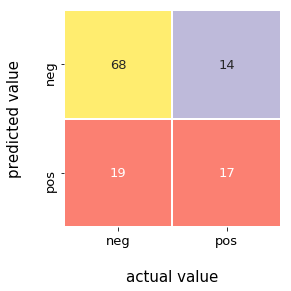

In [9]:
## show confustion matrix
show_confusion_matrix(y_test, y_pred)

In [10]:
accuracy_score(y_test, y_pred)

0.7203389830508474

In [11]:
recall_score(y_test, y_pred)

0.4722222222222222

In [12]:
precision_score(y_test, y_pred)

0.5483870967741935

In [13]:
f1_score(y_test, y_pred)

0.5074626865671641

How does logistic regression compare to other machine models we've tested so far?

## Wrapping up
In this module, we covered the basics of implementing and evaluating a logistic regression classifier in scikit learns.